In [35]:
%reload_ext autoreload
%autoreload 2
import sys, os
import pandas as pd
import warnings
import numpy as np
from sklearn.model_selection import train_test_split
from pathlib import Path

warnings.filterwarnings('ignore')
DATA_DIR = Path('../src/shared_util/data')
METRICS_DIR = DATA_DIR
CSV_PATH = METRICS_DIR / 'metrics.csv'
LOG = True



from shared_util.metrics import metrics_db
from shared_util.dataio import load_csv



if LOG:
    metrics_db.read_in(CSV_PATH)

METRICS_DB_ID = 0 # update this to not overwrite previous metrics for these models
METRIC_NOTES = "first pass" # global metric notes for this run



In [2]:
df = load_csv('cleaned')
df.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,target
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,0
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,?,...,No,Up,No,No,No,No,No,Ch,Yes,0
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,?,...,No,No,No,No,No,No,No,No,Yes,0
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,?,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,?,...,No,Steady,No,No,No,No,No,Ch,Yes,0


In [3]:
from shared_util.split import group_split

X_train, X_validate, X_test, y_train, y_validate, y_test = group_split(df)

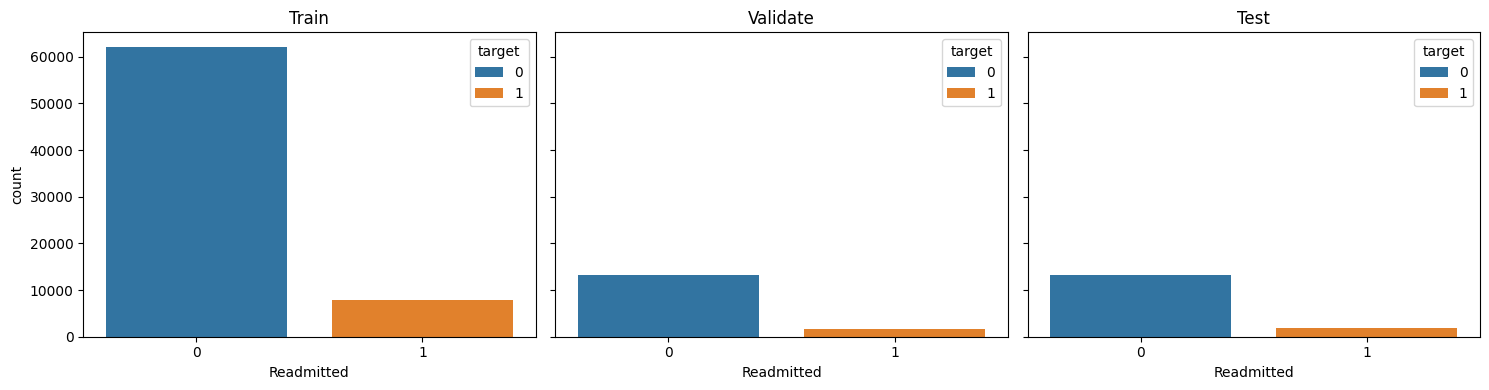

In [5]:
from shared_util.metrics.printing import check_y_dist

check_y_dist(
    y_train,
    y_validate,
    y_test
)

## Baseline

In [ ]:
import xgboost as xgb
from imblearn.under_sampling import RandomUnderSampler
from shared_util.pipeline import CleaningPipeline
from shared_util.baseline import get_baseline_score
from imblearn.pipeline import pipeline



In [ ]:
print('Baseline boosted tree')

clf = xgb.XGBClassifier(tree_method='hist', eval_metric='auc', n_estimators=600, random_state=42)

# pipe = Pipeline([
#     ('preprocessor', CleaningPipeline(create_interactions=False)),
#     ('sampler', RandomUnderSampler(random_state=42)),
#     ('model', clf)
# ])

# pipe.fit(X_train, y_train)


roc_auc = get_baseline_score(
    clf,
    RandomUnderSampler(random_state=42),
    X_train,
    y_train,
    preprocessor=CleaningPipeline(create_interactions=True)
    )


if LOG:
    metrics_db.log_metric(
        metric_id=METRICS_DB_ID,
        notes=METRIC_NOTES,
        model='xgboost',
        data='train',
        pipeline_notes='under_sample',
        roc_auc=roc_auc
    )

Baseline boosted tree
roc_auc score per fold:  [0.60748239 0.61225107 0.60762589 0.60035528 0.62435145]
mean roc_auc score:  0.6104132139823062
logged row: (0, xgboost, train, base, under_sample)


In [16]:
from imblearn.over_sampling import SMOTE

clf_smote = xgb.XGBClassifier(tree_method='hist', eval_metric='auc', n_estimators=600, random_state=42)
roc_auc = get_baseline_score(
    clf_smote,
    SMOTE(random_state=42),
    X_train,
    y_train,
    preprocessor=CleaningPipeline(create_interactions=True)
    )

if LOG:
    metrics_db.log_metric(
        metric_id=METRICS_DB_ID,
        notes=METRIC_NOTES,
        model='xgboost',
        data='train',
        pipeline_notes='SMOTE',
        roc_auc=roc_auc
    )


roc_auc score per fold:  [0.59092953 0.57675711 0.58833086 0.58182467 0.59172932]
mean roc_auc score:  0.5859142977266314
logged row: (0, xgboost, train, base, SMOTE)


In [29]:
# manually build out xgb pipe
from imblearn.pipeline import  Pipeline
from scipy.stats import randint as sp_randint, uniform, loguniform

def make_xgb_pipe(model=None):
    return Pipeline([
        ('preprocessor', CleaningPipeline(create_interactions=True)),
        ('model', model if model is not None else xgb.XGBClassifier(
            random_state=42,
            objective='binary:logistic',
            eval_metric='auc',
            tree_method='hist',
            device='cuda',
        ))
    ])

estimator = make_xgb_pipe()

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
approx_spw = float(neg / max(1, pos))

param_dist = {
    'model__n_estimators': sp_randint(200, 1500),
    'model__learning_rate': uniform(0.01, 0.29),
    'model__max_depth': sp_randint(2, 10),
    'model__min_child_weight': sp_randint(1, 10),
    'model__subsample': uniform(0.5, 0.5),
    'model__colsample_bytree': uniform(0.5, 0.5),
    'model__gamma': uniform(0.0, 5.0),
    'model__reg_alpha': loguniform(1e-8, 1e-1),
    'model__reg_lambda': loguniform(1e-2, 10),
    'model__scale_pos_weight': loguniform(max(approx_spw/5, 1e-3), approx_spw*5),
}

print(approx_spw)



7.938035007026958


The below cell uses an f2 (recall weighted score) to prevent the model chosing hyperparameters that end in a model that almost never predicts the positive class (but has the best ROC_AUC we told it to maximize before)

This is because 

In [ ]:
# ~18 min run on powerful workstation
from sklearn.model_selection import RandomizedSearchCV
from shared_util.baseline import make_group_cv
from shared_util.metrics.scoring import make_f2_scorer

f2_scorer = make_f2_scorer()

rs = RandomizedSearchCV(
    estimator=estimator,
    param_distributions=param_dist,
    n_iter=100,                    
    scoring=f2_scorer,
    cv=make_group_cv(),            
    n_jobs=-1,
    random_state=42,
    refit=True,
    verbose=1
)

rs.fit(X_train, y_train, groups=X_train['patient_nbr'])

print(f'Best F2 (cv): {rs.best_score_}')
print(f'best params: {rs.best_params_}')

res_df = pd.DataFrame(
    rs.cv_results_
).sort_values('rank_test_score').reset_index(drop=True)
res_df[['rank_test_score','mean_test_score','std_test_score','params']].head(10)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best ROC_AUC (cv): 0.4117927974257074
best params: {'model__colsample_bytree': np.float64(0.9745728657956929), 'model__gamma': np.float64(4.433401936490238), 'model__learning_rate': np.float64(0.08565915076909704), 'model__max_depth': 3, 'model__min_child_weight': 3, 'model__n_estimators': 641, 'model__reg_alpha': np.float64(3.2157271133712294e-05), 'model__reg_lambda': np.float64(0.41508051337392443), 'model__scale_pos_weight': np.float64(14.351038291187875), 'model__subsample': np.float64(0.8079255821949569)}


,rank_test_score,mean_test_score,std_test_score,params
0,1,0.411793,0.004417,{'model__colsample_bytree': 0.9745728657956929...
1,2,0.408323,0.004198,{'model__colsample_bytree': 0.9469462915254788...
2,3,0.403821,0.010644,{'model__colsample_bytree': 0.5335382386942138...
3,4,0.402624,0.004603,{'model__colsample_bytree': 0.9632247117948556...
4,5,0.400058,0.005737,{'model__colsample_bytree': 0.7447263801387816...
5,6,0.397348,0.008395,"{'model__colsample_bytree': 0.794977948568818,..."
6,7,0.395482,0.006206,{'model__colsample_bytree': 0.6465738651305066...
7,8,0.395206,0.010224,"{'model__colsample_bytree': 0.664375805143754,..."
8,9,0.395047,0.009496,{'model__colsample_bytree': 0.8317686860083553...
9,10,0.394585,0.006118,{'model__colsample_bytree': 0.5325257964926398...


In [ ]:
# Best ROC_AUC (cv): 0.6640249965352463
# best params: {'model__colsample_bytree': np.float64(0.5100355988888632), 'model__gamma': np.float64(1.6103958279158914), 'model__learning_rate': np.float64(0.07131992202899794), 'model__max_depth': 3, 'model__min_child_weight': 9, 'model__n_estimators': 344, 'model__reg_alpha': np.float64(2.5147108172305717e-06), 'model__reg_lambda': np.float64(0.2641860151813427), 'model__scale_pos_weight': np.float64(4.979176466085375), 'model__subsample': np.float64(0.8244114201457879)}

In [31]:
clf_auc_roc_weighted = xgb.XGBClassifier(
        colsample_bytree=float(0.5100355988888632),
        gamma=float(1.6103958279158914),
        learning_rate=float(0.07131992202899794),
        max_depth=3,
        min_child_weight=9,
        n_estimators=344,
        reg_alpha=float(2.5147108172305717e-06),
        reg_lambda=float(0.2641860151813427),
        scale_pos_weight=float(4.979176466085375),
        subsample=float(0.8244114201457879),
        random_state=42
    )

clf_f2_weighted = xgb.XGBClassifier(
        colsample_bytree=float(0.5100355988888632),
        gamma=float(1.6103958279158914),
        learning_rate=float(0.07131992202899794),
        max_depth=3,
        min_child_weight=9,
        n_estimators=344,
        reg_alpha=float(2.5147108172305717e-06),
        reg_lambda=float(0.2641860151813427),
        scale_pos_weight=float(4.979176466085375),
        subsample=float(0.8244114201457879),
        random_state=42
    )

USE_F2 = True

try:
    xgb_est = rs.best_estimator_
except:
    xgb_est = make_xgb_pipe(clf_f2_weighted if USE_F2 else clf_auc_roc_weighted)
    xgb_est.fit(X_train, y_train)


In [33]:
from shared_util.metrics.scoring import get_scores
from shared_util.metrics.printing import print_metrics

xgb_scores = get_scores(xgb_est, X_validate)

y_pred = xgb_est.predict(X_validate) #type: ignore

print_metrics(
              y_true=y_validate, 
              y_pred=y_pred, 
              y_proba=xgb_scores,
              data='validate',
              metrics_db_id=METRICS_DB_ID,
              metrics_notes=METRIC_NOTES,
              model='xgboost',
              hyperparam_notes=f'tuned best {('F2' if USE_F2 else 'roc_auc')}',
              pipeline_notes='under_sample',
              log=LOG
)

ROC_AUC:     0.658121710395701
Accuracy:      0.389343444422271
F1 score:      0.23728813559322035
Precision:     0.13815789473684212
Recall:        0.84

Confusion matrix:

TN: 4425, FP: 8908, FN: 272, TP: 1428

Classification report:
               precision    recall  f1-score   support

           0       0.94      0.33      0.49     13333
           1       0.14      0.84      0.24      1700

    accuracy                           0.39     15033
   macro avg       0.54      0.59      0.36     15033
weighted avg       0.85      0.39      0.46     15033

logged row: (0, xgboost, validate, base, under_sample)


No need to sweep threshold since we already weighted for F2 in the model training

In [36]:
xgb_scores_test = get_scores(xgb_est, X_test)

y_pred_test = xgb_est.predict(X_test) #type: ignore

print_metrics(
              y_true=y_test, 
              y_pred=y_pred_test, 
              y_proba=xgb_scores_test,
              data='test',
              threshold_notes='f2_weighted',
              metrics_db_id=METRICS_DB_ID,
              metrics_notes=METRIC_NOTES,
              model='xgboost',
              hyperparam_notes='tuned best F2',
              pipeline_notes='under_sample',
              log=LOG
              )

ROC_AUC:     0.6547606618211098
Accuracy:      0.3928098516949153
F1 score:      0.25042909685328973
Precision:     0.1472227561022487
Recall:        0.8376161837069437

Confusion matrix:

TN: 4401, FP: 8874, FN: 297, TP: 1532

Classification report:
               precision    recall  f1-score   support

           0       0.94      0.33      0.49     13275
           1       0.15      0.84      0.25      1829

    accuracy                           0.39     15104
   macro avg       0.54      0.58      0.37     15104
weighted avg       0.84      0.39      0.46     15104

logged row: (0, xgboost, test, f2_weighted, under_sample)


In [34]:
metrics_db.close(write=True)